In [1]:
%pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf

print(tf.__version__)


I0000 00:00:1790671207.881669    8313 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790671207.881892    8313 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790671208.059591    8313 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790671208.938131    8313 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2.21.0


In [4]:
# Feedforward Neural Network for MNIST Classification
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape :", x_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape : (10000, 28, 28)
Testing labels shape: (10000,)


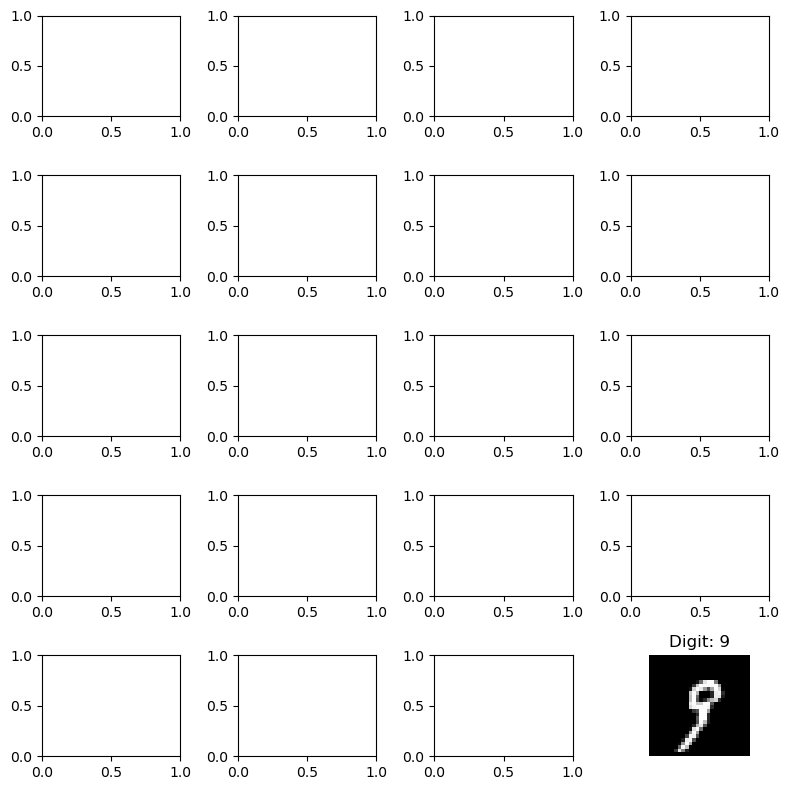

In [6]:
plt.figure(figsize=(8, 8))
for i in range(20):
    plt.subplot(5, 4, i + 1)
plt.imshow(x_train[i], cmap="gray")
plt.title("Digit: " + str(y_train[i]))
plt.axis("off")
plt.tight_layout()
plt.show()

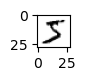

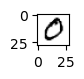

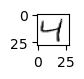

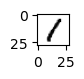

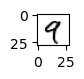

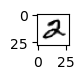

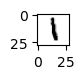

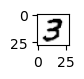

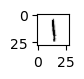

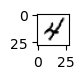

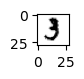

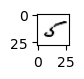

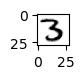

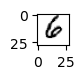

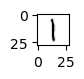

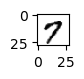

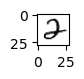

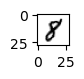

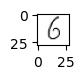

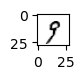

In [8]:
plt.figure(figsize=(5,5))
for k in range(20):
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys')
    plt.axis('on')
    plt.show()

In [10]:
# Convert each 28 x 28 image into a 784-element vector
x_train = x_train.reshape(x_train.shape[0], 784).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 784).astype("float32")

In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("After preprocessing:")
print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

After preprocessing:
Training data shape: (60000, 784)
Testing data shape : (10000, 784)


In [18]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPUs: []


In [19]:
model = Sequential([
Input(shape=(784,)),
# Hidden layer: 64 neurons
Dense(64, activation="sigmoid"),
# Output layer: 10 neurons for digits 0-9
Dense(10, activation="softmax")
])

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
optimizer=SGD(learning_rate=0.03),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

_IncompleteInputError: incomplete input (2245884216.py, line 7)

In [24]:
history = model.fit(
x_train,y_train,
batch_size=128,
epochs=20,
validation_split=0.1,
verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6316 - loss: 1.7119 - val_accuracy: 0.8133 - val_loss: 1.1811
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8080 - loss: 0.9841 - val_accuracy: 0.8712 - val_loss: 0.7367
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8457 - loss: 0.7103 - val_accuracy: 0.8925 - val_loss: 0.5589
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8640 - loss: 0.5847 - val_accuracy: 0.8997 - val_loss: 0.4671
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8745 - loss: 0.5132 - val_accuracy: 0.9067 - val_loss: 0.4127
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8817 - loss: 0.4670 - val_accuracy: 0.9098 - val_loss: 0.3768
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8875 - loss: 0.4346 - val_accuracy: 0.9147 - val_loss: 0.3513
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8915 - loss: 0.4107 - val_accuracy: 0.

In [25]:
test_loss, test_accuracy = model.evaluate(
x_test,
y_test,
verbose=0
)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.28480789065361023
Test Accuracy: 0.9200999736785889


In [26]:
y_probability = model.predict(x_test, verbose=0)

In [27]:
y_pred = np.argmax(y_probability, axis=1)

In [28]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 956    0    3    2    0    5    9    1    4    0]
 [   0 1103    2    2    1    2    4    2   19    0]
 [  10    3  920   15   15    1   11   16   36    5]
 [   2    1   19  922    0   23    1   15   22    5]
 [   1    5    5    0  912    1   11    2    9   36]
 [  11    2    7   50    9  757   14    9   26    7]
 [  11    3    5    1   14   12  908    1    3    0]
 [   2   10   26    5    6    0    0  945    2   32]
 [  10    8    6   23    8   17   13   10  872    7]
 [  12    7    2   12   37    7    1   18    7  906]]


In [29]:
print("\nClassification Report:")
print(
classification_report(
y_test,
y_pred,
zero_division=0
)
)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.97      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.89      0.91      0.90      1010
           4       0.91      0.93      0.92       982
           5       0.92      0.85      0.88       892
           6       0.93      0.95      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.90      0.88       974
           9       0.91      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



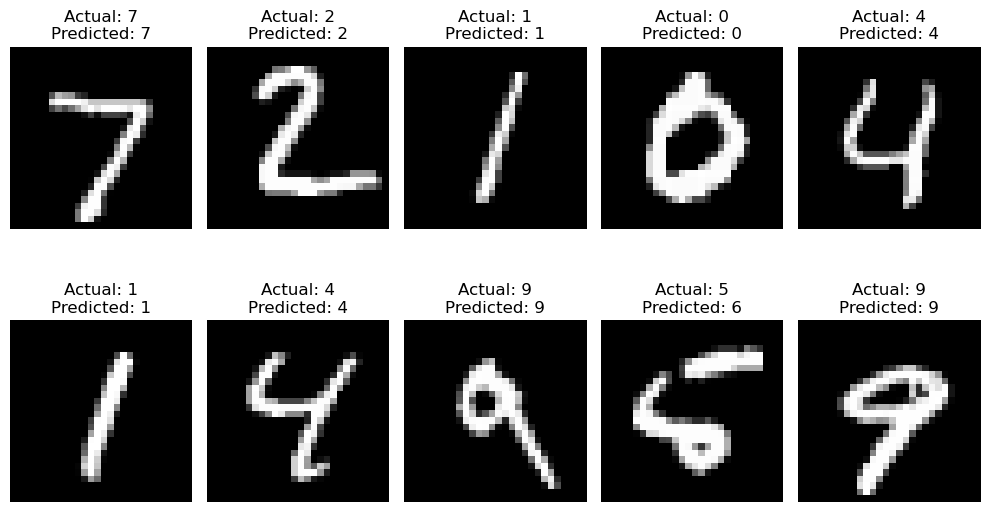

In [32]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape 784 values back to 28 x 28
    image = x_test[i].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.title(
    "Actual: " + str(y_test[i]) +
    "\nPredicted: " + str(y_pred[i])
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'epoch')

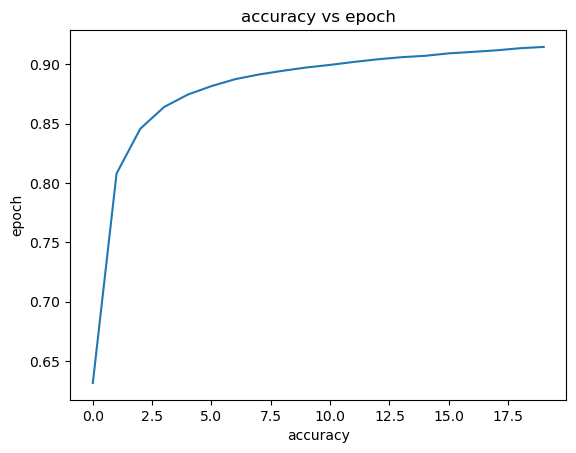

In [34]:
plt.plot(history.history['accuracy'])
plt.title('accuracy vs epoch')
plt.xlabel('accuracy')
plt.ylabel('epoch')

Text(0, 0.5, 'epoch')

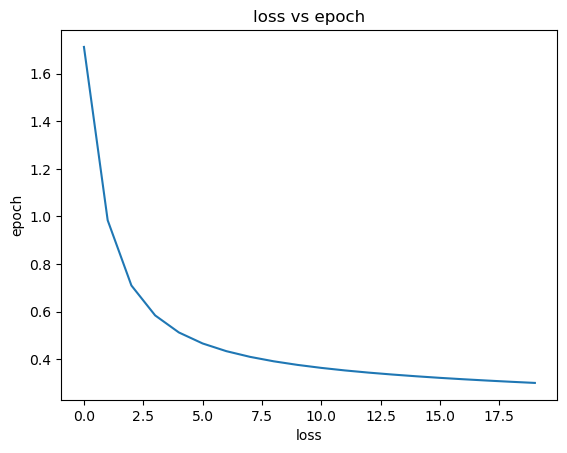

In [36]:
plt.plot(history.history['loss'])
plt.title('loss vs epoch')
plt.xlabel('loss')
plt.ylabel('epoch')
